# 1.1 Linearization & Discretization

Quadrotor dynamics $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}, \mathbf{u})$ are **nonlinear** (trig functions, products). MPC requires linear constraints, so we linearize via Taylor expansion.

## Discrete-Time Linear Model

$$\mathbf{x}_{k+1} \approx \mathbf{A}_k \mathbf{x}_k + \mathbf{B}_k \mathbf{u}_k + \mathbf{C}_k$$

$$\mathbf{A}_k = \mathbf{I} + \Delta t \cdot \frac{\partial\mathbf{f}}{\partial\mathbf{x}},\quad \mathbf{B}_k = \Delta t \cdot \frac{\partial\mathbf{f}}{\partial\mathbf{u}} + \frac{\Delta t^2}{2}\frac{\partial\mathbf{f}}{\partial\mathbf{x}}\frac{\partial\mathbf{f}}{\partial\mathbf{u}}$$

The **second-order B correction** captures cascade coupling: $\theta_c \to \dot{\theta} \to \theta \to \dot{v}_x \to v_x$.
Without it, at hover the model predicts **zero** velocity change from attitude commands — causing the MPC to be overly aggressive then oscillate.

$$\mathbf{C}_k = \mathbf{x}_{k+1}^{\text{true}} - \mathbf{A}_k\bar{\mathbf{x}} - \mathbf{B}_k\bar{\mathbf{u}}$$ ensures exact match at the linearization point.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, tan, atan2, sqrt, pi, erf, exp
from numpy.linalg import norm

# ── Parameters ──
g, kD = 9.81, 0.5
k_phi, k_theta, k_vz = 1.0, 1.0, 3.0
tau_phi, tau_theta, tau_vz = 0.2, 0.2, 0.4

def continuous_dynamics(x, u):
    phi, theta, psi = x[6], x[7], x[8]
    phi_c, theta_c, vz_c, psi_dot_c = u
    F_theta, F_phi = tan(theta), tan(phi)
    A_tilt = sqrt(1 + F_theta**2 + F_phi**2)
    if A_tilt > 1e-12:
        F_theta /= cos(theta) * A_tilt
        F_phi /= cos(phi) * A_tilt
    dx = np.zeros(9)
    dx[0:3] = x[3:6]
    dx[3] = g * F_theta * cos(psi) - g * F_phi * sin(psi) - kD * x[3]
    dx[4] = g * F_theta * sin(psi) + g * F_phi * cos(psi) - kD * x[4]
    dx[5] = (k_vz * vz_c - x[5]) / tau_vz
    dx[6] = (k_phi * phi_c - phi) / tau_phi
    dx[7] = (k_theta * theta_c - theta) / tau_theta
    dx[8] = psi_dot_c
    return dx

def discrete_step(x, u, dt):
    f = lambda xk: continuous_dynamics(xk, u)
    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

def jacobian_state(x, u, eps=1e-6):
    n = len(x)
    J = np.zeros((n, n))
    for i in range(n):
        dx = np.zeros(n)
        dx[i] = eps
        fp = continuous_dynamics(x + dx, u)
        fm = continuous_dynamics(x - dx, u)
        J[:, i] = (fp - fm) / (2.0 * eps)
    return J

def jacobian_control(x, u):
    J = np.zeros((9, 4))
    J[6, 0] = k_phi / tau_phi
    J[7, 1] = k_theta / tau_theta
    J[5, 2] = k_vz / tau_vz
    J[8, 3] = 1.0
    return J

def linearize(x_bar, u_bar, dt):
    A_cont = jacobian_state(x_bar, u_bar)
    B_cont = jacobian_control(x_bar, u_bar)
    A_k = np.eye(9) + dt * A_cont
    B_k = dt * B_cont + 0.5 * dt * dt * (A_cont @ B_cont)
    x_next = discrete_step(x_bar, u_bar, dt)
    C_k = x_next - A_k @ x_bar - B_k @ u_bar
    return A_k, B_k, C_k

_SQRT_PI_INV = 0.5641895835477563

def erfinv(y, tol=1e-12):
    if abs(y) >= 1.0:
        return float('inf') if y > 0 else float('-inf')
    if y == 0.0:
        return 0.0
    sign = 1.0 if y > 0 else -1.0
    ya = abs(y)
    a_const = 0.147
    t = 2.0 / (pi * a_const) + np.log(1.0 - ya * ya) / 2.0
    x = sign * sqrt(sqrt(t * t - np.log(1.0 - ya * ya) / a_const) - t)
    for _ in range(50):
        fx = erf(x) - y
        if abs(fx) < tol:
            break
        d = 2.0 * _SQRT_PI_INV * exp(-x * x)
        if abs(d) < 1e-300:
            x += 0.1 if x >= 0.0 else -0.1
            continue
        x -= fx / d
    return x

def yaw_to_rotation(yaw):
    ct, st = cos(yaw), sin(yaw)
    return np.array([[ct, -st, 0.0], [st, ct, 0.0], [0.0, 0.0, 1.0]])

def box_to_ellipsoid_axes(size):
    return 0.5 * sqrt(3.0) * np.array(size)

def Omega_matrix(axes, radius, R_o):
    inv_sq = 1.0 / (axes + radius)**2
    return R_o.T @ np.diag(inv_sq) @ R_o

def chance_constraint_rhs(L, Sigma_mav, Sigma_obs, n_o, delta):
    Sigma_combined = Sigma_mav + Sigma_obs
    inner_cov = L @ Sigma_combined @ L.T
    sigma_scaled = sqrt(2.0 * n_o @ inner_cov @ n_o)
    return erfinv(1.0 - 2.0 * delta) * sigma_scaled

print("All CC-MPC functions loaded and ready.")

# ── Compare first-order vs second-order B at hover ──
dt = 0.06
x_bar = np.zeros(9)
u_bar = np.zeros(4)

A_k, B_k, C_k = linearize(x_bar, u_bar, dt)
# First-order B (without correction)
A_cont = jacobian_state(x_bar, u_bar)
B_cont = jacobian_control(x_bar, u_bar)
B_k_1st = dt * B_cont

print("=== Critical Coupling: theta_c (pitch command) → vx (forward velocity) ===")
print(f"  First-order  B[3,1] (dvx/dtheta_c) = {B_k_1st[3,1]:.6f}  ← WRONG (zero!)")
print(f"  Second-order B[3,1] (dvx/dtheta_c) = {B_k[3,1]:.6f}  ← CORRECT")
expected = 9.81 * dt**2 / 2 * (1.0 / 0.2)
print(f"  Expected: g·dt²/2·(k_θ/τ_θ) = {expected:.6f}")
print()
print("With theta_c = 0.2 rad (≈ 11.5°):")
print(f"  First-order  Δvx = {B_k_1st[3,1] * 0.2:.6f} m/s  (WRONG)")
print(f"  Second-order Δvx = {B_k[3,1] * 0.2:.6f} m/s  (CORRECT)")


All CC-MPC functions loaded and ready.
=== Critical Coupling: theta_c (pitch command) → vx (forward velocity) ===
  First-order  B[3,1] (dvx/dtheta_c) = 0.000000  ← WRONG (zero!)
  Second-order B[3,1] (dvx/dtheta_c) = 0.088290  ← CORRECT
  Expected: g·dt²/2·(k_θ/τ_θ) = 0.088290

With theta_c = 0.2 rad (≈ 11.5°):
  First-order  Δvx = 0.000000 m/s  (WRONG)
  Second-order Δvx = 0.017658 m/s  (CORRECT)


C_k verification: max|linear - true| = 0.00e+00
  (should be < 1e-12)


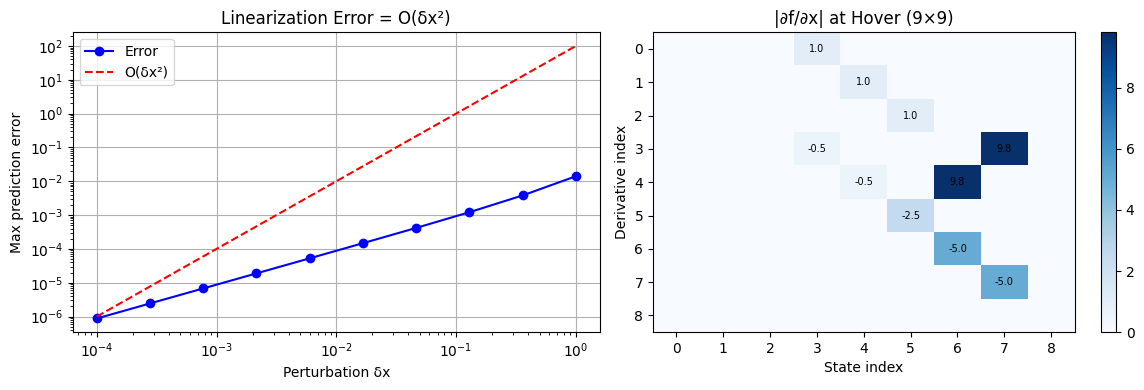

In [2]:

# ── Verify linearization accuracy ──
dt = 0.06
x_bar = np.zeros(9)
u_bar = np.zeros(4)
A_k, B_k, C_k = linearize(x_bar, u_bar, dt)

# Verify C_k: linear model EXACT at expansion point
x_next_true = discrete_step(x_bar, u_bar, dt)
x_next_linear = A_k @ x_bar + B_k @ u_bar + C_k
print(f"C_k verification: max|linear - true| = {np.max(np.abs(x_next_linear - x_next_true)):.2e}")
print(f"  (should be < 1e-12)")

# Perturbation accuracy test
perturbations = np.logspace(-4, 0, 10)
errors = []
for eps_val in perturbations:
    dx = np.ones(9) * eps_val * 0.1
    x_pert = x_bar + dx
    x_true = discrete_step(x_pert, u_bar, dt)
    x_lin = A_k @ x_pert + B_k @ u_bar + C_k
    errors.append(np.max(np.abs(x_true - x_lin)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.loglog(perturbations, errors, 'b-o', label='Error')
ax1.loglog(perturbations, perturbations**2 * 100, 'r--', label='O(δx²)')
ax1.set_xlabel('Perturbation δx'); ax1.set_ylabel('Max prediction error')
ax1.set_title('Linearization Error = O(δx²)'); ax1.legend(); ax1.grid(True)

# Show Jacobian structure
A_cont = jacobian_state(x_bar, u_bar)
im = ax2.imshow(np.abs(A_cont), cmap='Blues', aspect='auto')
ax2.set_title('|∂f/∂x| at Hover (9×9)'); ax2.set_xlabel('State index'); ax2.set_ylabel('Derivative index')
for i in range(9):
    for j in range(9):
        if abs(A_cont[i,j]) > 0.01:
            ax2.text(j, i, f'{A_cont[i,j]:.1f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.savefig('outputs/1.1_linearization.png', dpi=100, bbox_inches='tight')
plt.show()


## Summary

- **Second-order B correction** critical at hover — captures cascade coupling $\theta_c \to v_x$
- **Affine offset $\mathbf{C}_k$** ensures exact match at linearization point
- **Error $O(\delta x^2)$** — accurate for small perturbations
- **Finite-difference Jacobian** — 81 entries, fast enough for 9D state

**Next**: [[1.2 Reference Trajectory]] → [[2.0 Linear MPC]]